/tmp/ipykernel_3933/159165149.py:28: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


Dataset Shape: (100000, 28)
       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Cr

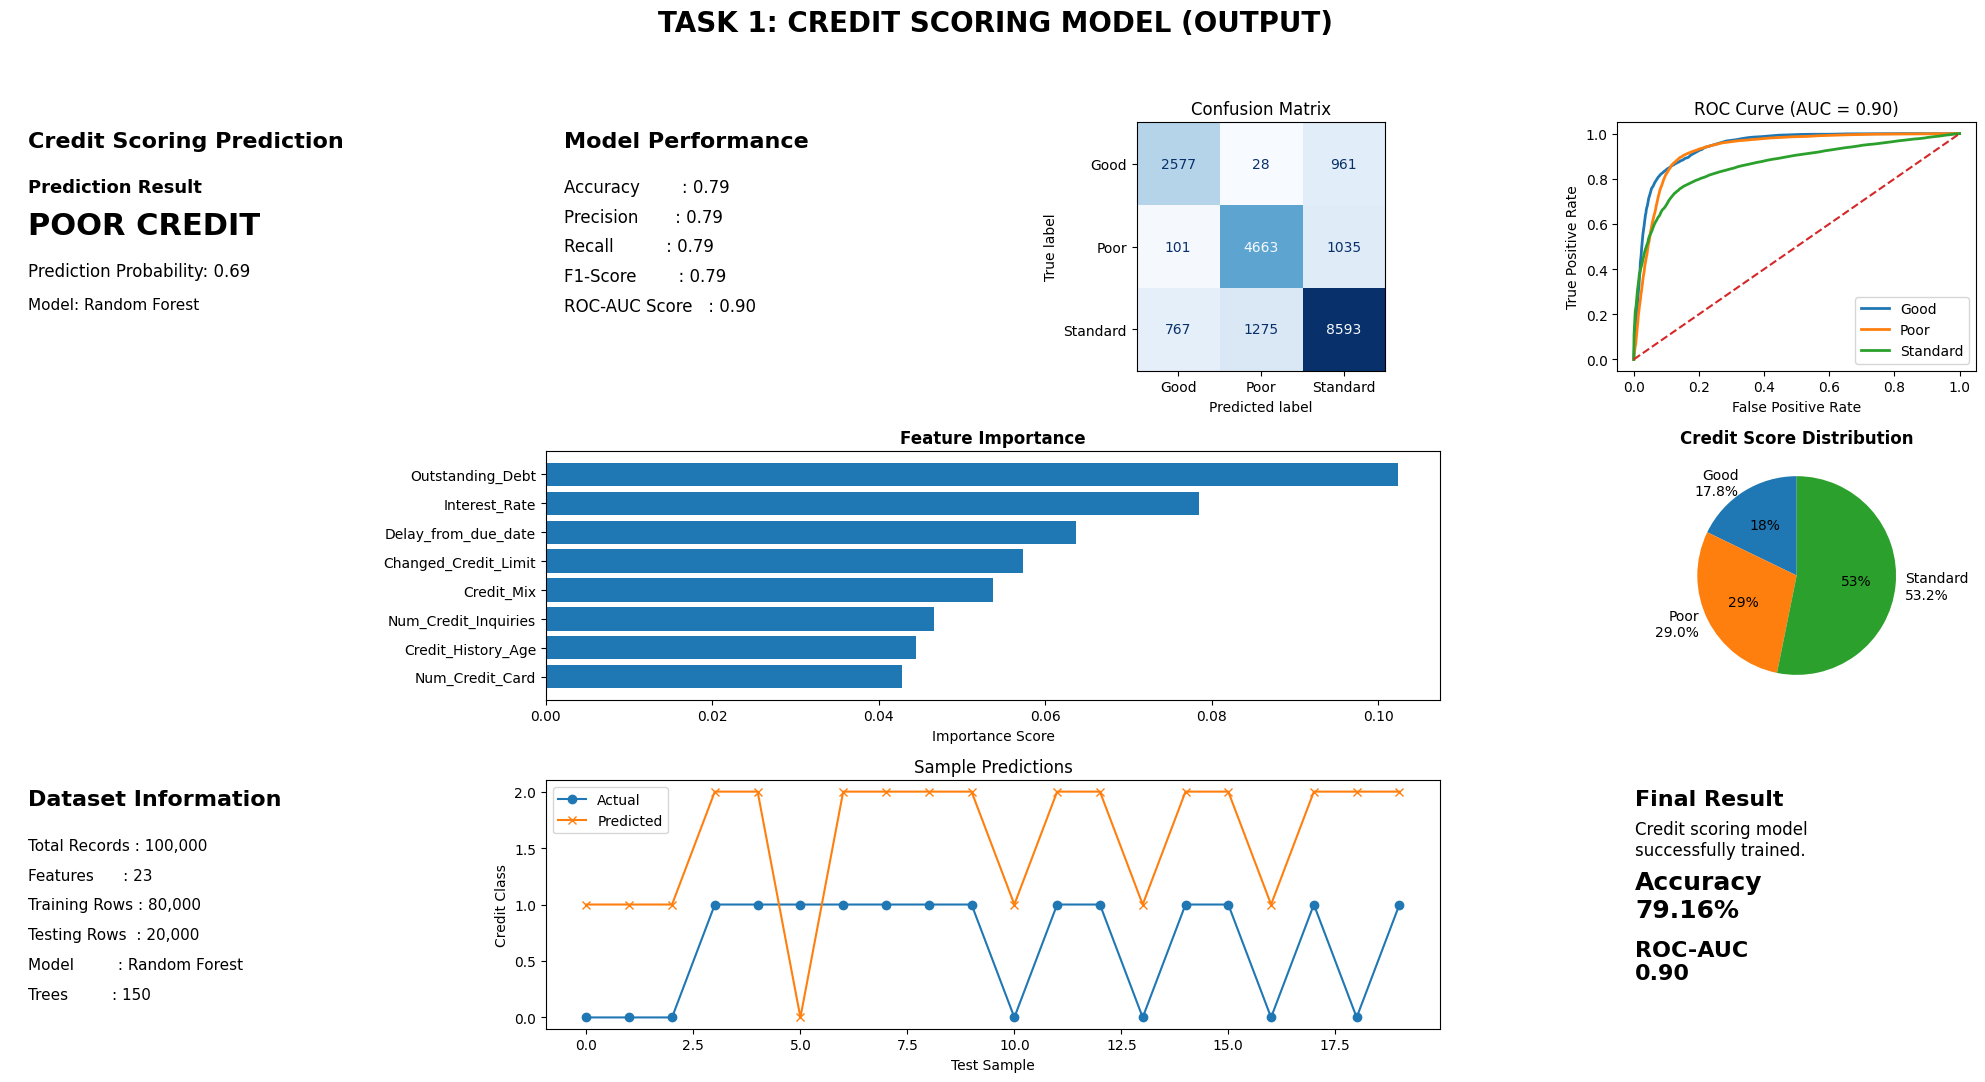


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.75      0.72      0.74      3566
        Poor       0.78      0.80      0.79      5799
    Standard       0.81      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000



In [ ]:
# ============================================
# CODEALPHA TASK 1 - CREDIT SCORING MODEL
# Dashboard-style output
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ============================================
# 2. CLEAN COLUMN NAMES
# ============================================

df.columns = df.columns.str.strip()

# ============================================
# 3. REMOVE UNNECESSARY COLUMNS
# ============================================

remove_columns = [
    "ID",
    "Customer_ID",
    "Name",
    "SSN"
]

for col in remove_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# ============================================
# 4. CLEAN OBJECT VALUES
# ============================================

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace("_", "", regex=False)

# ============================================
# 5. TARGET COLUMN
# ============================================

target = "Credit_Score"

if target not in df.columns:
    raise ValueError(
        f"'{target}' column not found. Available columns:\n{df.columns.tolist()}"
    )

# ============================================
# 6. CONVERT NUMERIC COLUMNS
# ============================================

for col in df.columns:
    if col != target:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

# ============================================
# 7. HANDLE MISSING VALUES
# ============================================

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col != target:
        df[col] = df[col].fillna(df[col].mode()[0])

# ============================================
# 8. ENCODE CATEGORICAL FEATURES
# ============================================

for col in df.select_dtypes(include="object").columns:
    if col != target:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col])

# ============================================
# 9. ENCODE TARGET
# ============================================

target_encoder = LabelEncoder()

df[target] = target_encoder.fit_transform(df[target])

print("\nTarget Classes:")
print(target_encoder.classes_)

# ============================================
# 10. FEATURES AND TARGET
# ============================================

X = df.drop(target, axis=1)
y = df[target]

# ============================================
# 11. TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================
# 12. SCALE
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 13. RANDOM FOREST MODEL
# ============================================

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

# ============================================
# 14. PREDICTION
# ============================================

y_pred = model.predict(X_test_scaled)

y_probability = model.predict_proba(X_test_scaled)

# ============================================
# 15. METRICS
# ============================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

# Multiclass ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_probability,
    multi_class="ovr",
    average="weighted"
)

print("\n================================")
print("CREDIT SCORING MODEL")
print("================================")

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")
print(f"ROC-AUC   : {roc_auc:.2f}")

# ============================================
# 16. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

# ============================================
# 17. FEATURE IMPORTANCE
# ============================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# ============================================
# 18. CREDIT SCORE DISTRIBUTION
# ============================================

class_counts = pd.Series(y).value_counts().sort_index()

class_names = target_encoder.inverse_transform(
    class_counts.index
)

# ============================================
# 19. CREATE DASHBOARD
# ============================================

fig = plt.figure(figsize=(20, 11))

fig.suptitle(
    "TASK 1: CREDIT SCORING MODEL (OUTPUT)",
    fontsize=20,
    fontweight="bold"
)

# --------------------------------------------
# PANEL 1 - Prediction Example
# --------------------------------------------

ax1 = plt.subplot2grid((3, 4), (0, 0))
ax1.axis("off")

prediction_class = target_encoder.inverse_transform(
    [y_pred[0]]
)[0]

probability = max(y_probability[0])

ax1.text(
    0.05,
    0.90,
    "Credit Scoring Prediction",
    fontsize=16,
    fontweight="bold"
)

ax1.text(
    0.05,
    0.72,
    "Prediction Result",
    fontsize=13,
    fontweight="bold"
)

ax1.text(
    0.05,
    0.55,
    str(prediction_class).upper() + " CREDIT",
    fontsize=22,
    fontweight="bold"
)

ax1.text(
    0.05,
    0.38,
    f"Prediction Probability: {probability:.2f}",
    fontsize=12
)

ax1.text(
    0.05,
    0.25,
    "Model: Random Forest",
    fontsize=11
)

# --------------------------------------------
# PANEL 2 - Model Performance
# --------------------------------------------

ax2 = plt.subplot2grid((3, 4), (0, 1))
ax2.axis("off")

ax2.text(
    0.05,
    0.90,
    "Model Performance",
    fontsize=16,
    fontweight="bold"
)

metrics = [
    ("Accuracy", accuracy),
    ("Precision", precision),
    ("Recall", recall),
    ("F1-Score", f1),
    ("ROC-AUC Score", roc_auc)
]

y_pos = 0.72

for name, value in metrics:
    ax2.text(
        0.05,
        y_pos,
        f"{name:<16}: {value:.2f}",
        fontsize=12
    )
    y_pos -= 0.12

# --------------------------------------------
# PANEL 3 - Confusion Matrix
# --------------------------------------------

ax3 = plt.subplot2grid((3, 4), (0, 2))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(
    ax=ax3,
    cmap="Blues",
    colorbar=False
)

ax3.set_title("Confusion Matrix")

# --------------------------------------------
# PANEL 4 - ROC Curve
# --------------------------------------------

ax4 = plt.subplot2grid((3, 4), (0, 3))

if len(target_encoder.classes_) == 2:

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability[:, 1]
    )

    ax4.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"ROC Curve (AUC = {roc_auc:.2f})"
    )

    ax4.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax4.set_xlabel("False Positive Rate")
    ax4.set_ylabel("True Positive Rate")
    ax4.set_title("ROC Curve")
    ax4.legend()

else:

    from sklearn.preprocessing import label_binarize

    y_test_binary = label_binarize(
        y_test,
        classes=np.arange(len(target_encoder.classes_))
    )

    for i in range(len(target_encoder.classes_)):

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, i],
            y_probability[:, i]
        )

        ax4.plot(
            fpr,
            tpr,
            linewidth=2,
            label=target_encoder.classes_[i]
        )

    ax4.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax4.set_xlabel("False Positive Rate")
    ax4.set_ylabel("True Positive Rate")
    ax4.set_title(
        f"ROC Curve (AUC = {roc_auc:.2f})"
    )

    ax4.legend()

# --------------------------------------------
# PANEL 5 - Feature Importance
# --------------------------------------------

ax5 = plt.subplot2grid((3, 4), (1, 1), colspan=2)

top_features = importance.head(8).sort_values()

ax5.barh(
    top_features.index,
    top_features.values
)

ax5.set_title(
    "Feature Importance",
    fontweight="bold"
)

ax5.set_xlabel("Importance Score")

# --------------------------------------------
# PANEL 6 - Credit Distribution
# --------------------------------------------

ax6 = plt.subplot2grid((3, 4), (1, 3))

ax6.pie(
    class_counts.values,
    labels=[
        f"{name}\n{count / len(y) * 100:.1f}%"
        for name, count in zip(
            class_names,
            class_counts.values
        )
    ],
    autopct="%1.0f%%",
    startangle=90
)

ax6.set_title(
    "Credit Score Distribution",
    fontweight="bold"
)

# --------------------------------------------
# PANEL 7 - Dataset Information
# --------------------------------------------

ax7 = plt.subplot2grid((3, 4), (2, 0))
ax7.axis("off")

ax7.text(
    0.05,
    0.90,
    "Dataset Information",
    fontsize=16,
    fontweight="bold"
)

dataset_info = [
    f"Total Records : {len(df):,}",
    f"Features      : {X.shape[1]}",
    f"Training Rows : {len(X_train):,}",
    f"Testing Rows  : {len(X_test):,}",
    "Model         : Random Forest",
    "Trees         : 150"
]

y_pos = 0.72

for text in dataset_info:
    ax7.text(
        0.05,
        y_pos,
        text,
        fontsize=11
    )
    y_pos -= 0.12

# --------------------------------------------
# PANEL 8 - Actual vs Predicted
# --------------------------------------------

ax8 = plt.subplot2grid((3, 4), (2, 1), colspan=2)

comparison = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(y_test[:20]),
    "Predicted": target_encoder.inverse_transform(y_pred[:20])
})

x = np.arange(len(comparison))

ax8.plot(
    x,
    comparison["Actual"].astype("category").cat.codes,
    marker="o",
    label="Actual"
)

ax8.plot(
    x,
    comparison["Predicted"].astype("category").cat.codes,
    marker="x",
    label="Predicted"
)

ax8.set_title("Sample Predictions")
ax8.set_xlabel("Test Sample")
ax8.set_ylabel("Credit Class")
ax8.legend()

# --------------------------------------------
# PANEL 9 - Final Result
# --------------------------------------------

ax9 = plt.subplot2grid((3, 4), (2, 3))
ax9.axis("off")

ax9.text(
    0.05,
    0.90,
    "Final Result",
    fontsize=16,
    fontweight="bold"
)

ax9.text(
    0.05,
    0.70,
    "Credit scoring model\nsuccessfully trained.",
    fontsize=12
)

ax9.text(
    0.05,
    0.45,
    f"Accuracy\n{accuracy * 100:.2f}%",
    fontsize=18,
    fontweight="bold"
)

ax9.text(
    0.05,
    0.20,
    f"ROC-AUC\n{roc_auc:.2f}",
    fontsize=16,
    fontweight="bold"
)

# ============================================
# FINAL LAYOUT
# ============================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

# ============================================
# PRINT CLASSIFICATION REPORT
# ============================================

print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)